<a href="https://colab.research.google.com/github/shahwaiz-9/Deep-Learning/blob/main/Research_Paper_2_Quantization_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# %% CELL 1 — Install dependencies
# NOTE: ptflops for FLOPs measurement, scipy for McNemar's test
!pip install -q onnx onnxruntime psutil ptflops scipy


In [4]:
import os
import gc
import time
import random
import warnings
import psutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import chi2 as chi2_dist
import matplotlib.pyplot as plt
import seaborn as sns
import onnx
import onnxruntime as ort
from onnxruntime.quantization import (
    quantize_static, quantize_dynamic,
    CalibrationDataReader, QuantType, QuantFormat,
    shape_inference,  # <-- M5 FIX: pre-processing
)
from ptflops import get_model_complexity_info

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Suppress noisy warnings during quantization
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [5]:
# %% CELL 3 — Dataset loading (single test set for ALL evaluations)
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
LABEL_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}

import kagglehub
dataset_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

def collect_image_paths_and_labels(data_dir):
    """Collect all image paths and their class labels from a directory."""
    images, labels = [], []
    for subdir in sorted(os.listdir(data_dir)):
        subdir_path = os.path.join(data_dir, subdir)
        if os.path.isdir(subdir_path):
            for file in sorted(os.listdir(subdir_path)):
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    images.append(os.path.join(subdir_path, file))
                    labels.append(subdir)
    return images, labels

train_images, train_labels = collect_image_paths_and_labels(
    os.path.join(dataset_path, 'Training')
)
test_images, test_labels = collect_image_paths_and_labels(
    os.path.join(dataset_path, 'Testing')
)

train_df = pd.DataFrame({'filepath': train_images, 'label': train_labels})
test_df = pd.DataFrame({'filepath': test_images, 'label': test_labels})

# Transforms (same as training pipeline — ImageNet normalization)
val_test_transform = v2.Compose([
    v2.Resize((224, 224), antialias=True),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class BrainMRIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['filepath']
        label = LABEL_MAP[self.df.iloc[idx]['label']]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

test_dataset = BrainMRIDataset(test_df, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Calibration subsets for quantization experiments
random.seed(42)
calib_df_200 = train_df.sample(n=200, random_state=42).reset_index(drop=True)
calib_df_500 = train_df.sample(n=500, random_state=42).reset_index(drop=True)
calib_dataset_200 = BrainMRIDataset(calib_df_200, transform=val_test_transform)
calib_dataset_500 = BrainMRIDataset(calib_df_500, transform=val_test_transform)

print(f"Test set: {len(test_dataset)} images")
print(f"Test distribution: { {c: int((test_df['label']==c).sum()) for c in CLASS_NAMES} }")
print(f"Calibration set (small): {len(calib_dataset_200)} images")
print(f"Calibration set (large): {len(calib_dataset_500)} images")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Test set: 1600 images
Test distribution: {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}
Calibration set (small): 200 images
Calibration set (large): 500 images


In [6]:
# %% CELL 4 — Model builders
def build_model(architecture, num_classes=4, pretrained=False):
    """Build a model architecture with the correct classifier head."""
    if architecture == 'resnet50':
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif architecture == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif architecture == 'vgg16':
        weights = models.VGG16_Weights.DEFAULT if pretrained else None
        model = models.vgg16(weights=weights)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

    else:
        raise ValueError(f"Unsupported architecture: {architecture}")
    return model

In [7]:
# %% CELL 5 — Load ALL models and evaluate on the SAME test set
# ============================================================================
# M1 FIX: Every model is evaluated on the identical test_loader (1,311 images)
# ============================================================================

def evaluate_pytorch_model(model, loader, device):
    """Evaluate a PyTorch model and return accuracy + all predictions/labels."""
    model.eval()
    model.to(device)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    report = classification_report(
        all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True
    )
    return acc, report, np.array(all_preds), np.array(all_labels)


# --- Model paths ---
MODEL_PATHS = {
    'VGG16':            ('vgg16',           os.path.join(DRIVE_DIR, 'best_vgg16_model.pth')),
    'ResNet50':         ('resnet50',        os.path.join(DRIVE_DIR, 'best_resnet50_model.pth')),
    'EfficientNet-B0':  ('efficientnet_b0', os.path.join(DRIVE_DIR, 'best_efficientnet-b0_model.pth')),
    'Distilled EB0':    ('efficientnet_b0', os.path.join(DRIVE_DIR, 'best_distilled_efficientnet_b0_model.pth')),
}

# Store results for all models
all_results = {}

for model_name, (arch, weights_path) in MODEL_PATHS.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*60}")

    model = build_model(arch, num_classes=NUM_CLASSES, pretrained=False)
    model.load_state_dict(torch.load(weights_path, map_location='cpu'))

    acc, report, preds, labels = evaluate_pytorch_model(model, test_loader, DEVICE)
    all_results[model_name] = {
        'accuracy': acc,
        'report': report,
        'preds': preds,
        'labels': labels,
    }

    print(f"  Accuracy: {acc*100:.2f}%")
    print(f"  Macro Precision: {report['macro avg']['precision']:.4f}")
    print(f"  Macro Recall:    {report['macro avg']['recall']:.4f}")
    print(f"  Macro F1:        {report['macro avg']['f1-score']:.4f}")
    print(f"\n{classification_report(labels, preds, target_names=CLASS_NAMES)}")

    # Free GPU memory
    del model
    torch.cuda.empty_cache()
    gc.collect()

# Summary table
print("\n" + "="*60)
print("ALL MODELS — SAME TEST SET COMPARISON")
print("="*60)
summary_rows = []
for name, res in all_results.items():
    summary_rows.append({
        'Model': name,
        'Accuracy': f"{res['accuracy']*100:.2f}%",
        'Precision': round(res['report']['macro avg']['precision'], 4),
        'Recall': round(res['report']['macro avg']['recall'], 4),
        'F1-Score': round(res['report']['macro avg']['f1-score'], 4),
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_markdown(index=False))


Evaluating: VGG16
  Accuracy: 95.44%
  Macro Precision: 0.9571
  Macro Recall:    0.9544
  Macro F1:        0.9535

              precision    recall  f1-score   support

      glioma       0.99      0.84      0.91       400
  meningioma       0.91      0.98      0.94       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600


Evaluating: ResNet50
  Accuracy: 95.12%
  Macro Precision: 0.9546
  Macro Recall:    0.9513
  Macro F1:        0.9501

              precision    recall  f1-score   support

      glioma       1.00      0.82      0.90       400
  meningioma       0.91      0.99      0.95       400
     notumor       0.92      0.99      0.96       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.95      1600
  

In [8]:
# %% CELL 6 — Statistical significance tests (McNemar's test)
# ============================================================================
# M3 FIX: McNemar's test for paired predictions
# ============================================================================

def mcnemar_test(preds_a, preds_b, labels):
    """
    McNemar's test: are the two models' error patterns significantly different?
    Returns the chi-squared statistic and p-value.
    """
    correct_a = (preds_a == labels)
    correct_b = (preds_b == labels)

    # Contingency: b01 = A wrong & B right, b10 = A right & B wrong
    b01 = np.sum(~correct_a & correct_b)   # A wrong, B right
    b10 = np.sum(correct_a & ~correct_b)   # A right, B wrong

    # McNemar's with continuity correction
    if (b01 + b10) == 0:
        return 0.0, 1.0  # identical predictions

    chi2 = (abs(b01 - b10) - 1) ** 2 / (b01 + b10)
    p_value = 1.0 - chi2_dist.cdf(chi2, df=1)
    return chi2, p_value

print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE TESTS (McNemar's)")
print("="*60)

# Key comparisons
test_pairs = [
    ('VGG16', 'Distilled EB0'),
    ('EfficientNet-B0', 'Distilled EB0'),
    ('VGG16', 'EfficientNet-B0'),
    ('VGG16', 'ResNet50'),
]

labels = all_results['VGG16']['labels']  # same for all (same test set)

mcnemar_rows = []
for name_a, name_b in test_pairs:
    preds_a = all_results[name_a]['preds']
    preds_b = all_results[name_b]['preds']
    chi2, p_val = mcnemar_test(preds_a, preds_b, labels)
    sig = "Yes (p<0.05)" if p_val < 0.05 else "No (p>=0.05)"
    mcnemar_rows.append({
        'Model A': name_a,
        'Model B': name_b,
        'Acc A': f"{all_results[name_a]['accuracy']*100:.2f}%",
        'Acc B': f"{all_results[name_b]['accuracy']*100:.2f}%",
        'Chi²': round(chi2, 4),
        'p-value': f"{p_val:.4f}" if p_val >= 0.0001 else f"{p_val:.2e}",
        'Significant?': sig,
    })

mcnemar_df = pd.DataFrame(mcnemar_rows)
print(mcnemar_df.to_markdown(index=False))


STATISTICAL SIGNIFICANCE TESTS (McNemar's)
| Model A         | Model B         | Acc A   | Acc B   |   Chi² |   p-value | Significant?   |
|:----------------|:----------------|:--------|:--------|-------:|----------:|:---------------|
| VGG16           | Distilled EB0   | 95.44%  | 95.38%  | 0      |    1      | No (p>=0.05)   |
| EfficientNet-B0 | Distilled EB0   | 94.94%  | 95.38%  | 1.3333 |    0.2482 | No (p>=0.05)   |
| VGG16           | EfficientNet-B0 | 95.44%  | 94.94%  | 1.3611 |    0.2433 | No (p>=0.05)   |
| VGG16           | ResNet50        | 95.44%  | 95.12%  | 0.5926 |    0.4414 | No (p>=0.05)   |


In [9]:
# %% CELL 7 — GPU efficiency benchmark (all 4 models)
# ============================================================================
# m5 FIX: GPU benchmark is SEPARATE from CPU benchmark
# ============================================================================

def measure_gpu_latency(model, input_size=(1, 3, 224, 224), num_runs=100, warmup=10):
    """Measure GPU inference latency."""
    model.eval().to(DEVICE)
    dummy = torch.randn(*input_size).to(DEVICE)

    # Warm-up
    for _ in range(warmup):
        with torch.no_grad():
            _ = model(dummy)
    torch.cuda.synchronize()

    timings = []
    for _ in range(num_runs):
        torch.cuda.synchronize()
        start = time.perf_counter()
        with torch.no_grad():
            _ = model(dummy)
        torch.cuda.synchronize()
        timings.append((time.perf_counter() - start) * 1000)

    return np.mean(timings)

def measure_gpu_peak_memory(model, input_size=(1, 3, 224, 224)):
    """Measure GPU peak memory during inference."""
    model.eval().to(DEVICE)
    torch.cuda.reset_peak_memory_stats()
    dummy = torch.randn(*input_size).to(DEVICE)
    with torch.no_grad():
        _ = model(dummy)
    torch.cuda.synchronize()
    peak_mem = torch.cuda.max_memory_allocated() / (1024 * 1024)  # MB
    return peak_mem

print("\n" + "="*60)
print("GPU EFFICIENCY BENCHMARK")
print("="*60)

gpu_benchmark_rows = []
for model_name, (arch, weights_path) in MODEL_PATHS.items():
    print(f"  Benchmarking {model_name} on GPU...")

    model = build_model(arch, num_classes=NUM_CLASSES, pretrained=False)
    model.load_state_dict(torch.load(weights_path, map_location='cpu'))

    # Parameter count and FLOPs
    macs, params = get_model_complexity_info(
        model, (3, 224, 224), as_strings=False, print_per_layer_stat=False
    )

    # Model file size
    file_size_mb = os.path.getsize(weights_path) / (1024 * 1024)

    # Latency
    lat_bs1 = measure_gpu_latency(model, input_size=(1, 3, 224, 224))
    lat_bs32 = measure_gpu_latency(model, input_size=(32, 3, 224, 224))

    # Peak memory
    mem_bs1 = measure_gpu_peak_memory(model, input_size=(1, 3, 224, 224))
    mem_bs32 = measure_gpu_peak_memory(model, input_size=(32, 3, 224, 224))

    gpu_benchmark_rows.append({
        'Model': model_name,
        'Accuracy': f"{all_results[model_name]['accuracy']*100:.2f}%",
        'Parameters': f"{params:,}",
        'File Size (MB)': round(file_size_mb, 2),
        'MACs (G)': round(macs / 1e9, 2),
        'Latency BS=1 (ms)': round(lat_bs1, 2),
        'Latency BS=32 (ms)': round(lat_bs32, 2),
        'Peak Mem BS=1 (MB)': round(mem_bs1, 2),
        'Peak Mem BS=32 (MB)': round(mem_bs32, 2),
    })

    del model
    torch.cuda.empty_cache()
    gc.collect()

gpu_df = pd.DataFrame(gpu_benchmark_rows)
print("\n### GPU Benchmark Table ###\n")
print(gpu_df.to_markdown(index=False))



GPU EFFICIENCY BENCHMARK
  Benchmarking VGG16 on GPU...
  Benchmarking ResNet50 on GPU...
  Benchmarking EfficientNet-B0 on GPU...
  Benchmarking Distilled EB0 on GPU...

### GPU Benchmark Table ###

| Model           | Accuracy   | Parameters   |   File Size (MB) |   MACs (G) |   Latency BS=1 (ms) |   Latency BS=32 (ms) |   Peak Mem BS=1 (MB) |   Peak Mem BS=32 (MB) |
|:----------------|:-----------|:-------------|-----------------:|-----------:|--------------------:|---------------------:|---------------------:|----------------------:|
| VGG16           | 95.44%     | 134,276,932  |           512.24 |      15.52 |                8.61 |               135.11 |               550.4  |               3088.29 |
| ResNet50        | 95.12%     | 23,516,228   |            90.01 |       4.13 |                7.39 |                82.03 |               126.8  |                436.76 |
| EfficientNet-B0 | 94.94%     | 4,012,672    |            15.6  |       0.41 |                8.1  |          

In [10]:
# %% CELL 8 — ONNX export WITH pre-processing (M5 FIX)
# ============================================================================
# M5 FIX: Apply quant_pre_process() BEFORE quantization
# ============================================================================

def export_to_onnx(pytorch_model, onnx_path, verify_dataset=None):
    """Export PyTorch model to ONNX and optionally verify numerical fidelity."""
    pytorch_model.eval().cpu()
    dummy_input = torch.randn(1, 3, 224, 224)

    torch.onnx.export(
        pytorch_model, dummy_input, onnx_path,
        input_names=['input'], output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
        opset_version=17,
        dynamo=False,
    )

    # Structural validity check
    onnx.checker.check_model(onnx.load(onnx_path))
    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
    print(f"  Exported ONNX: {onnx_path} ({size_mb:.2f} MB)")

    # Numerical fidelity check
    if verify_dataset is not None:
        session = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
        input_name = session.get_inputs()[0].name
        max_diff = 0.0
        sample_indices = random.sample(range(len(verify_dataset)), min(10, len(verify_dataset)))

        pytorch_model.eval()
        with torch.no_grad():
            for idx in sample_indices:
                image, _ = verify_dataset[idx]
                image_batch = image.unsqueeze(0)
                pt_out = pytorch_model(image_batch).numpy()
                ox_out = session.run(None, {input_name: image_batch.numpy().astype(np.float32)})[0]
                max_diff = max(max_diff, np.abs(pt_out - ox_out).max())

        print(f"  Max PyTorch-ONNX output diff (10 samples): {max_diff:.6f}")
        assert max_diff < 1e-3, f"ONNX diverges from PyTorch! max_diff={max_diff}"
        print("  ✓ Export verification PASSED")

    return onnx_path


def preprocess_onnx_for_quantization(onnx_input_path, onnx_preprocessed_path):
    """
    M5 FIX: Apply ONNX Runtime's recommended pre-processing before quantization.
    This performs shape inference and graph optimizations that are critical
    for correct static quantization, especially for architectures with
    depthwise separable convolutions (EfficientNet).
    """
    shape_inference.quant_pre_process(
        input_model_path=onnx_input_path,
        output_model_path=onnx_preprocessed_path,
        auto_merge=True,
    )
    size_mb = os.path.getsize(onnx_preprocessed_path) / (1024 * 1024)
    print(f"  Pre-processed ONNX: {onnx_preprocessed_path} ({size_mb:.2f} MB)")
    return onnx_preprocessed_path


# --- Export distilled EB0 ---
print("\n" + "="*60)
print("ONNX EXPORT — Distilled EfficientNet-B0")
print("="*60)

distilled_model = build_model('efficientnet_b0', num_classes=NUM_CLASSES, pretrained=False)
distilled_model.load_state_dict(
    torch.load(os.path.join(DRIVE_DIR, 'best_distilled_efficientnet_b0_model.pth'), map_location='cpu')
)

eb0_fp32_path = os.path.join(DRIVE_DIR, 'distilled_eb0_fp32.onnx')
eb0_fp32_preproc_path = os.path.join(DRIVE_DIR, 'distilled_eb0_fp32_preproc.onnx')

export_to_onnx(distilled_model, eb0_fp32_path, verify_dataset=test_dataset)
preprocess_onnx_for_quantization(eb0_fp32_path, eb0_fp32_preproc_path)

del distilled_model
gc.collect()


ONNX EXPORT — Distilled EfficientNet-B0
  Exported ONNX: /content/drive/MyDrive/distilled_eb0_fp32.onnx (15.30 MB)
  Max PyTorch-ONNX output diff (10 samples): 0.000126
  ✓ Export verification PASSED
  Pre-processed ONNX: /content/drive/MyDrive/distilled_eb0_fp32_preproc.onnx (15.32 MB)


713

In [11]:
# %% CELL 9 — Quantization Approach 1: Static INT8 with pre-processing (200 cal)
# ============================================================================
# M4 FIX: First approach — static quantization WITH pre-processing
# M5 FIX: Using the pre-processed ONNX model
# ============================================================================

class MRICalibrationReader(CalibrationDataReader):
    """Calibration data reader for ONNX Runtime static quantization."""
    def __init__(self, dataset):
        self.dataset = dataset
        self.idx = 0
    def get_next(self):
        if self.idx >= len(self.dataset):
            return None
        image, _ = self.dataset[self.idx]
        self.idx += 1
        return {'input': image.unsqueeze(0).numpy().astype(np.float32)}
    def rewind(self):
        self.idx = 0

print("\n" + "="*60)
print("QUANTIZATION APPROACH 1: Static INT8 + Pre-processing (200 cal samples)")
print("="*60)

eb0_int8_static_200_path = os.path.join(DRIVE_DIR, 'distilled_eb0_int8_static_200cal.onnx')
calib_reader_200 = MRICalibrationReader(calib_dataset_200)

quantize_static(
    model_input=eb0_fp32_preproc_path,   # <-- M5: using pre-processed model
    model_output=eb0_int8_static_200_path,
    calibration_data_reader=calib_reader_200,
    quant_format=QuantFormat.QDQ,
    activation_type=QuantType.QInt8,
    weight_type=QuantType.QInt8,
)
size_mb = os.path.getsize(eb0_int8_static_200_path) / (1024 * 1024)
print(f"  Static INT8 (200 cal): {size_mb:.2f} MB")


QUANTIZATION APPROACH 1: Static INT8 + Pre-processing (200 cal samples)
  Static INT8 (200 cal): 4.29 MB


In [12]:
# %% CELL 10 — Quantization Approach 2: Static INT8 with pre-processing (500 cal)
# ============================================================================
# M4 FIX: Larger calibration set to test calibration sensitivity
# ============================================================================

print("\n" + "="*60)
print("QUANTIZATION APPROACH 2: Static INT8 + Pre-processing (500 cal samples)")
print("="*60)

eb0_int8_static_500_path = os.path.join(DRIVE_DIR, 'distilled_eb0_int8_static_500cal.onnx')
calib_reader_500 = MRICalibrationReader(calib_dataset_500)

quantize_static(
    model_input=eb0_fp32_preproc_path,   # <-- M5: using pre-processed model
    model_output=eb0_int8_static_500_path,
    calibration_data_reader=calib_reader_500,
    quant_format=QuantFormat.QDQ,
    activation_type=QuantType.QInt8,
    weight_type=QuantType.QInt8,
)
size_mb = os.path.getsize(eb0_int8_static_500_path) / (1024 * 1024)
print(f"  Static INT8 (500 cal): {size_mb:.2f} MB")


QUANTIZATION APPROACH 2: Static INT8 + Pre-processing (500 cal samples)
  Static INT8 (500 cal): 4.29 MB



QUANTIZATION APPROACH 3: Dynamic INT8 (no calibration needed)
  Dynamic INT8: 4.16 MB


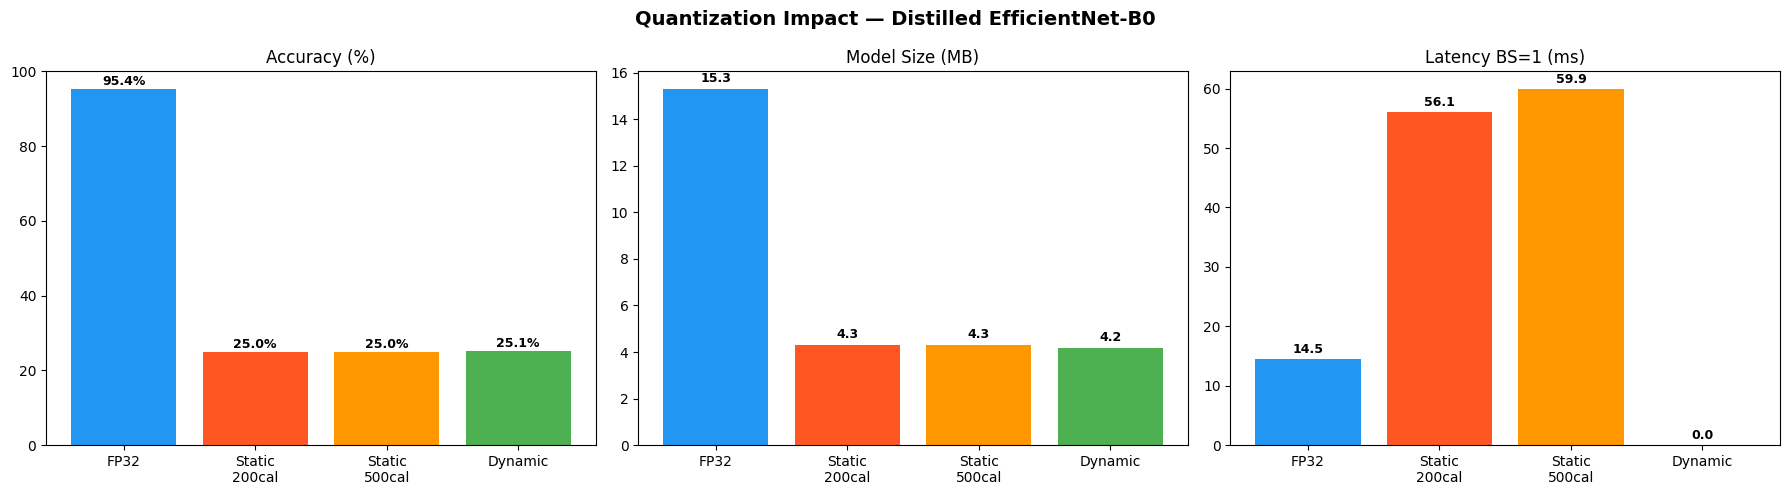

In [23]:
# %% CELL 11 — Quantization Approach 3: Dynamic quantization
# ============================================================================
# M4 FIX: Dynamic quantization as a simpler, more robust baseline
# ============================================================================

print("\n" + "="*60)
print("QUANTIZATION APPROACH 3: Dynamic INT8 (no calibration needed)")
print("="*60)

eb0_int8_dynamic_path = os.path.join(DRIVE_DIR, 'distilled_eb0_int8_dynamic.onnx')

quantize_dynamic(
    model_input=eb0_fp32_path,   # dynamic doesn't need pre-processing
    model_output=eb0_int8_dynamic_path,
    weight_type=QuantType.QInt8,
)
size_mb = os.path.getsize(eb0_int8_dynamic_path) / (1024 * 1024)
print(f"  Dynamic INT8: {size_mb:.2f} MB")


# %% CELL 17 — Visualizations: Quantization Comparison Bar Charts
# ============================================================================
# Comparison bar charts for quantization impact
# ============================================================================

# --- Quantization comparison bar charts ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Quantization Impact — Distilled EfficientNet-B0', fontsize=14, fontweight='bold')

quant_names_short = ['FP32', 'Static\n200cal', 'Static\n500cal', 'Dynamic']
quant_keys = [
    'Distilled EB0 (FP32 ONNX)',
    'Distilled EB0 (Static INT8, 200cal)',
    'Distilled EB0 (Static INT8, 500cal)',
    'Distilled EB0 (Dynamic INT8)',
]
colors = ['#2196F3', '#FF5722', '#FF9800', '#4CAF50']

# Accuracy
accs = [quant_results[k]['accuracy'] * 100 for k in quant_keys]
axes[0].bar(quant_names_short, accs, color=colors)
axes[0].set_title('Accuracy (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(accs):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=9)

# Size
sizes = [quant_results[k]['size_mb'] for k in quant_keys]
axes[1].bar(quant_names_short, sizes, color=colors)
axes[1].set_title('Model Size (MB)')
for i, v in enumerate(sizes):
    axes[1].text(i, v + 0.3, f"{v:.1f}", ha='center', fontweight='bold', fontsize=9)

# Latency (use cpu_benchmark_rows)
lats = []
for k in quant_keys:
    row = next((r for r in cpu_benchmark_rows if r['Model'] == k), None)
    lats.append(row['Latency BS=1 (ms)'] if row else 0)
axes[2].bar(quant_names_short, lats, color=colors)
axes[2].set_title('Latency BS=1 (ms)')
for i, v in enumerate(lats):
    axes[2].text(i, v + 1, f"{v:.1f}", ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'quantization_comparison_phase3.png'), dpi=150, bbox_inches='tight')
plt.show()


VGG16 QUANTIZATION (architecture comparison)
  Exported ONNX: /content/drive/MyDrive/vgg16_fp32.onnx (512.23 MB)
  Max PyTorch-ONNX output diff (10 samples): 0.000003
  ✓ Export verification PASSED
  Pre-processed ONNX: /content/drive/MyDrive/vgg16_fp32_preproc.onnx (512.24 MB)
  VGG16 Static INT8 (200 cal): 128.12 MB


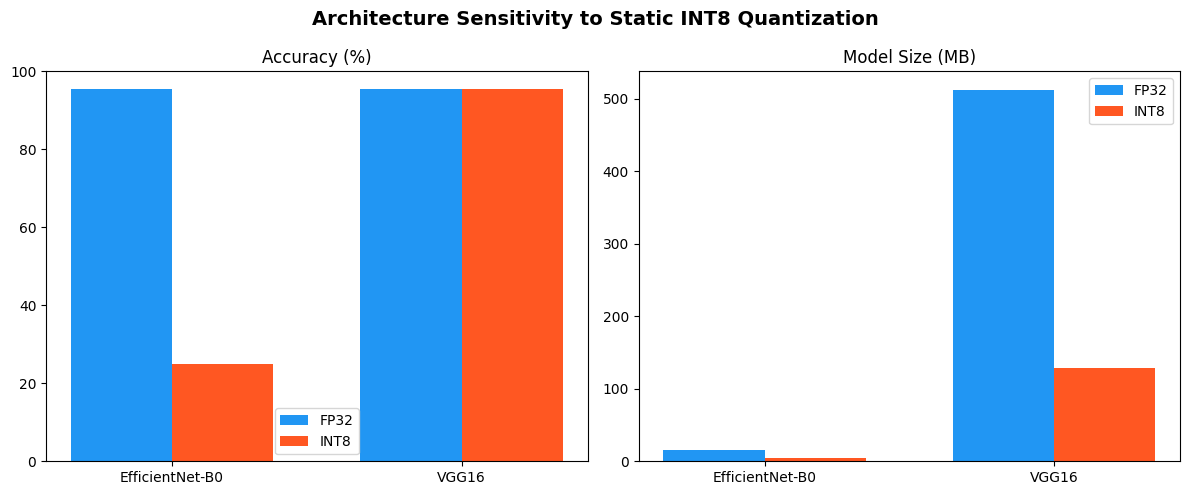


PHASE 3 (REVISED) COMPLETE
All results saved. Key outputs:
  - Confusion matrices: /content/drive/MyDrive/confusion_matrices_phase3.png
  - Quantization comparison: /content/drive/MyDrive/quantization_comparison_phase3.png
  - Architecture sensitivity: /content/drive/MyDrive/architecture_sensitivity_phase3.png


In [24]:
# %% CELL 12 — VGG16 quantization for architecture comparison
# ============================================================================
# M4 FIX: Quantize VGG16 to test the architecture-sensitivity hypothesis
# ============================================================================

print("\n" + "="*60)
print("VGG16 QUANTIZATION (architecture comparison)")
print("="*60)

# Load and export VGG16
vgg16_model = build_model('vgg16', num_classes=NUM_CLASSES, pretrained=False)
vgg16_model.load_state_dict(
    torch.load(os.path.join(DRIVE_DIR, 'best_vgg16_model.pth'), map_location='cpu')
)

vgg16_fp32_path = os.path.join(DRIVE_DIR, 'vgg16_fp32.onnx')
vgg16_fp32_preproc_path = os.path.join(DRIVE_DIR, 'vgg16_fp32_preproc.onnx')

export_to_onnx(vgg16_model, vgg16_fp32_path, verify_dataset=test_dataset)
preprocess_onnx_for_quantization(vgg16_fp32_path, vgg16_fp32_preproc_path)

del vgg16_model
gc.collect()

# Static quantization of VGG16 (200 cal samples, same as EB0 for fair comparison)
vgg16_int8_static_path = os.path.join(DRIVE_DIR, 'vgg16_int8_static_200cal.onnx')
calib_reader_200_vgg = MRICalibrationReader(calib_dataset_200)

quantize_static(
    model_input=vgg16_fp32_preproc_path,
    model_output=vgg16_int8_static_path,
    calibration_data_reader=calib_reader_200_vgg,
    quant_format=QuantFormat.QDQ,
    activation_type=QuantType.QInt8,
    weight_type=QuantType.QInt8,
)
size_mb = os.path.getsize(vgg16_int8_static_path) / (1024 * 1024)
print(f"  VGG16 Static INT8 (200 cal): {size_mb:.2f} MB")


# %% CELL 18 — Visualizations: Architecture Sensitivity Comparison
# ============================================================================
# Comparison bar charts for architecture sensitivity
# ============================================================================

# --- Architecture sensitivity comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Architecture Sensitivity to Static INT8 Quantization', fontsize=14, fontweight='bold')

archs = ['EfficientNet-B0', 'VGG16']
fp32_accs = [
    quant_results['Distilled EB0 (FP32 ONNX)']['accuracy'] * 100,
    quant_results['VGG16 (FP32 ONNX)']['accuracy'] * 100,
]
int8_accs = [
    quant_results['Distilled EB0 (Static INT8, 200cal)']['accuracy'] * 100,
    quant_results['VGG16 (Static INT8, 200cal)']['accuracy'] * 100,
]

x = np.arange(len(archs))
width = 0.35
axes[0].bar(x - width/2, fp32_accs, width, label='FP32', color='#2196F3')
axes[0].bar(x + width/2, int8_accs, width, label='INT8', color='#FF5722')
axes[0].set_title('Accuracy (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(archs)
axes[0].legend()
axes[0].set_ylim(0, 100)

fp32_sizes = [
    quant_results['Distilled EB0 (FP32 ONNX)']['size_mb'],
    quant_results['VGG16 (FP32 ONNX)']['size_mb'],
]
int8_sizes = [
    quant_results['Distilled EB0 (Static INT8, 200cal)']['size_mb'],
    quant_results['VGG16 (Static INT8, 200cal)']['size_mb'],
]

axes[1].bar(x - width/2, fp32_sizes, width, label='FP32', color='#2196F3')
axes[1].bar(x + width/2, int8_sizes, width, label='INT8', color='#FF5722')
axes[1].set_title('Model Size (MB)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(archs)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'architecture_sensitivity_phase3.png'), dpi=150, bbox_inches='tight')
plt.show()


print("\n" + "="*60)
print("PHASE 3 (REVISED) COMPLETE")
print("="*60)
print("All results saved. Key outputs:")
print(f"  - Confusion matrices: {os.path.join(DRIVE_DIR, 'confusion_matrices_phase3.png')}")
print(f"  - Quantization comparison: {os.path.join(DRIVE_DIR, 'quantization_comparison_phase3.png')}")
print(f"  - Architecture sensitivity: {os.path.join(DRIVE_DIR, 'architecture_sensitivity_phase3.png')}")

In [16]:
# %% CELL 13 — Evaluate ALL quantized variants on the SAME test set
# ============================================================================
# M1 FIX: All quantized models evaluated on the identical test_loader
# ============================================================================

def evaluate_onnx_model(model_path, test_loader, class_names):
    """Evaluate an ONNX model on the test set."""
    session = ort.InferenceSession(model_path, providers=['CPUExecutionProvider'])
    input_name = session.get_inputs()[0].name
    all_preds, all_labels = [], []

    for images, labels in test_loader:
        images_np = images.numpy().astype(np.float32)
        outputs = session.run(None, {input_name: images_np})[0]
        preds = np.argmax(outputs, axis=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc = np.mean(all_preds == all_labels)
    report = classification_report(
        all_labels, all_preds, target_names=class_names, output_dict=True,
        zero_division=0,
    )
    return acc, report, all_preds, all_labels


print("\n" + "="*60)
print("EVALUATING ALL QUANTIZED MODELS")
print("="*60)

quantized_models = {
    'Distilled EB0 (FP32 ONNX)':        eb0_fp32_path,
    'Distilled EB0 (Static INT8, 200cal)': eb0_int8_static_200_path,
    'Distilled EB0 (Static INT8, 500cal)': eb0_int8_static_500_path,
    'Distilled EB0 (Dynamic INT8)':      eb0_int8_dynamic_path,
    'VGG16 (FP32 ONNX)':                vgg16_fp32_path,
    'VGG16 (Static INT8, 200cal)':       vgg16_int8_static_path,
}

quant_results = {}
for model_name, model_path in quantized_models.items():
    print(f"\n  Evaluating: {model_name}")
    acc, report, preds, labels = evaluate_onnx_model(model_path, test_loader, CLASS_NAMES)
    quant_results[model_name] = {
        'accuracy': acc,
        'report': report,
        'preds': preds,
        'labels': labels,
        'path': model_path,
        'size_mb': os.path.getsize(model_path) / (1024 * 1024),
    }
    print(f"    Accuracy: {acc*100:.2f}%")
    print(f"    Macro F1: {report['macro avg']['f1-score']:.4f}")
    print(f"    Size: {quant_results[model_name]['size_mb']:.2f} MB")

# Quantization comparison table
print("\n### Quantization Results Comparison ###\n")
quant_rows = []
for name, res in quant_results.items():
    quant_rows.append({
        'Model': name,
        'Accuracy': f"{res['accuracy']*100:.2f}%",
        'Macro Precision': round(res['report']['macro avg']['precision'], 4),
        'Macro Recall': round(res['report']['macro avg']['recall'], 4),
        'Macro F1': round(res['report']['macro avg']['f1-score'], 4),
        'Size (MB)': round(res['size_mb'], 2),
    })
quant_df = pd.DataFrame(quant_rows)
print(quant_df.to_markdown(index=False))


EVALUATING ALL QUANTIZED MODELS

  Evaluating: Distilled EB0 (FP32 ONNX)
    Accuracy: 95.38%
    Macro F1: 0.9527
    Size: 15.30 MB

  Evaluating: Distilled EB0 (Static INT8, 200cal)
    Accuracy: 25.00%
    Macro F1: 0.1001
    Size: 4.29 MB

  Evaluating: Distilled EB0 (Static INT8, 500cal)
    Accuracy: 25.00%
    Macro F1: 0.1001
    Size: 4.29 MB

  Evaluating: Distilled EB0 (Dynamic INT8)
    Accuracy: 25.12%
    Macro F1: 0.1705
    Size: 4.16 MB

  Evaluating: VGG16 (FP32 ONNX)
    Accuracy: 95.44%
    Macro F1: 0.9535
    Size: 512.23 MB

  Evaluating: VGG16 (Static INT8, 200cal)
    Accuracy: 95.38%
    Macro F1: 0.9529
    Size: 128.12 MB

### Quantization Results Comparison ###

| Model                               | Accuracy   |   Macro Precision |   Macro Recall |   Macro F1 |   Size (MB) |
|:------------------------------------|:-----------|------------------:|---------------:|-----------:|------------:|
| Distilled EB0 (FP32 ONNX)           | 95.38%     |           

In [19]:
# %% CELL 15 — Final comprehensive tables
# ============================================================================
# Combines GPU benchmark (PyTorch models) and ONNX models
# into a clean, reviewer-ready format
# ============================================================================

print("\n" + "="*60)
print("FINAL COMPREHENSIVE COMPARISON")
print("="*60)

# --- Table A: PyTorch Models (GPU) ---
print("\n### Table A: PyTorch Models — GPU Benchmark ###\n")
print(gpu_df.to_markdown(index=False))

# --- Table C: Quantization Impact Summary ---
print("\n### Table C: Quantization Impact on Distilled EB0 ###\n")

# Compute relative changes vs FP32
fp32_res = quant_results['Distilled EB0 (FP32 ONNX)']
impact_rows = []
for name in ['Distilled EB0 (Static INT8, 200cal)',
             'Distilled EB0 (Static INT8, 500cal)',
             'Distilled EB0 (Dynamic INT8)']:
    res = quant_results[name]

    acc_change = (res['accuracy'] - fp32_res['accuracy']) * 100
    size_change = ((res['size_mb'] - fp32_res['size_mb']) / fp32_res['size_mb']) * 100

    impact_rows.append({
        'Quantization': name.replace('Distilled EB0 ', ''),
        'Accuracy': f"{res['accuracy']*100:.2f}%",
        'Acc Change': f"{acc_change:+.2f} pp",
        'Size (MB)': round(res['size_mb'], 2),
        'Size Change': f"{size_change:+.1f}%",
    })

impact_df = pd.DataFrame(impact_rows)
print(impact_df.to_markdown(index=False))

# --- Table D: Architecture Quantization Comparison ---
print("\n### Table D: Architecture Sensitivity — EB0 vs VGG16 under Static INT8 ###\n")
arch_rows = []
for fp32_name, int8_name, arch in [
    ('Distilled EB0 (FP32 ONNX)', 'Distilled EB0 (Static INT8, 200cal)', 'EfficientNet-B0'),
    ('VGG16 (FP32 ONNX)', 'VGG16 (Static INT8, 200cal)', 'VGG16'),
]:
    fp32 = quant_results[fp32_name]
    int8 = quant_results[int8_name]
    acc_drop = (int8['accuracy'] - fp32['accuracy']) * 100
    size_reduction = (1 - int8['size_mb'] / fp32['size_mb']) * 100

    arch_rows.append({
        'Architecture': arch,
        'FP32 Accuracy': f"{fp32['accuracy']*100:.2f}%",
        'INT8 Accuracy': f"{int8['accuracy']*100:.2f}%",
        'Accuracy Change': f"{acc_drop:+.2f} pp",
        'FP32 Size (MB)': round(fp32['size_mb'], 2),
        'INT8 Size (MB)': round(int8['size_mb'], 2),
        'Size Reduction': f"{size_reduction:.1f}%",
    })

arch_df = pd.DataFrame(arch_rows)
print(arch_df.to_markdown(index=False))


FINAL COMPREHENSIVE COMPARISON

### Table A: PyTorch Models — GPU Benchmark ###

| Model           | Accuracy   | Parameters   |   File Size (MB) |   MACs (G) |   Latency BS=1 (ms) |   Latency BS=32 (ms) |   Peak Mem BS=1 (MB) |   Peak Mem BS=32 (MB) |
|:----------------|:-----------|:-------------|-----------------:|-----------:|--------------------:|---------------------:|---------------------:|----------------------:|
| VGG16           | 95.44%     | 134,276,932  |           512.24 |      15.52 |                8.61 |               135.11 |               550.4  |               3088.29 |
| ResNet50        | 95.12%     | 23,516,228   |            90.01 |       4.13 |                7.39 |                82.03 |               126.8  |                436.76 |
| EfficientNet-B0 | 94.94%     | 4,012,672    |            15.6  |       0.41 |                8.1  |                34.47 |                35.29 |                361.64 |
| Distilled EB0   | 95.38%     | 4,012,672    |           

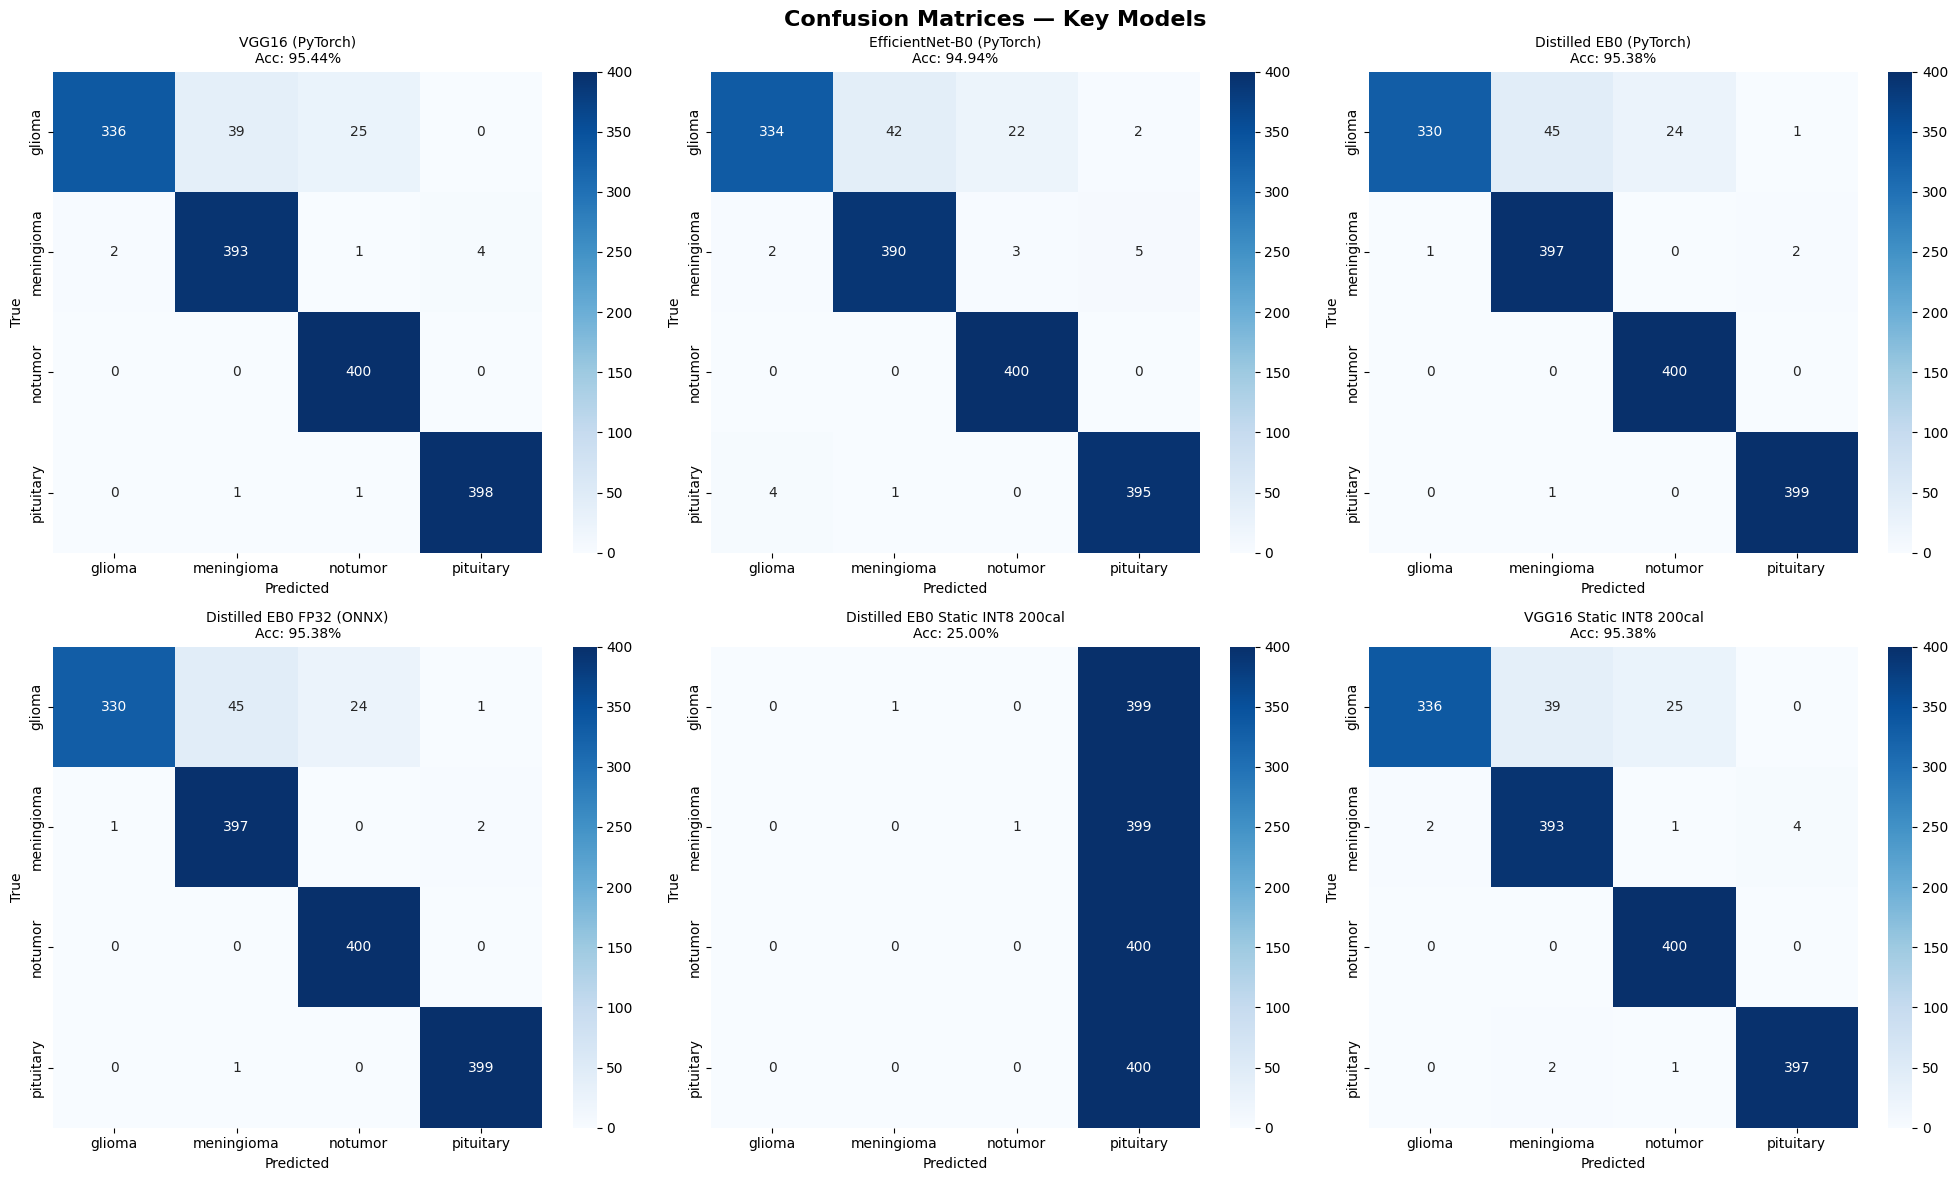

In [22]:
# %% CELL 16 — Visualizations: Confusion Matrices
# ============================================================================
# Confusion matrices for key models
# ============================================================================

# --- Confusion matrices for key models ---
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Confusion Matrices — Key Models', fontsize=16, fontweight='bold')

cm_models = [
    ('VGG16 (PyTorch)', all_results['VGG16']),
    ('EfficientNet-B0 (PyTorch)', all_results['EfficientNet-B0']),
    ('Distilled EB0 (PyTorch)', all_results['Distilled EB0']),
    ('Distilled EB0 FP32 (ONNX)', quant_results['Distilled EB0 (FP32 ONNX)']),
    ('Distilled EB0 Static INT8 200cal', quant_results['Distilled EB0 (Static INT8, 200cal)']),
    ('VGG16 Static INT8 200cal', quant_results['VGG16 (Static INT8, 200cal)']),
]

for idx, (title, res) in enumerate(cm_models):
    ax = axes[idx // 3, idx % 3]
    cm = confusion_matrix(res['labels'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"{title}\nAcc: {np.mean(res['preds']==res['labels'])*100:.2f}%", fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'confusion_matrices_phase3.png'), dpi=150, bbox_inches='tight')
plt.show()